# Phần 3 — Mô hình Dự báo Doanh thu (Revenue & COGS)
## Datathon 2026 — Vòng 1

**Mục tiêu:** Dự báo doanh thu hàng ngày (`Revenue`) và giá vốn (`COGS`)
cho giai đoạn **2023-01-01 → 2024-07-01** từ dữ liệu lịch sử 2012–2022.

**Chiến lược Ensemble:**

| Model | Phương pháp | Đặc điểm |
|-------|-------------|-----------|
| Model A | Seasonal Profile × Geometric Trend | Baseline cải tiến, dùng năm gần đây |
| Model B | Fourier Ridge Regression | Hồi quy tuyến tính với Fourier features đa mùa vụ |
| Model C | **LightGBM** | GBDT với calendar + seasonal features *(tốt nhất)* |
| Model D | **XGBoost** | GBDT alternative *(tốt nhất)* |
| **Final** | **Best-2 Ensemble (C+D)** | **Weighted average LightGBM + XGBoost** |

**Metrics đánh giá:** MAE ↓, RMSE ↓, R² ↑
**Validation:** 2021–2022 (giữ lại, không dùng huấn luyện)


## 1. Import thư viện

In [1]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

BASE  = "."          # Thư mục chứa sales.csv
OUT_F = "submission_part3.csv"
print("Libraries loaded OK")


Libraries loaded OK


## 2. Nạp & Khảo sát dữ liệu

In [2]:
raw = pd.read_csv(os.path.join(BASE, "sales.csv"), parse_dates=["Date"])
raw = raw.sort_values("Date").reset_index(drop=True)

test_dates = pd.date_range("2023-01-01", "2024-07-01", freq="D")
test_raw   = pd.DataFrame({"Date": test_dates})

print(f"Train: {raw['Date'].min().date()} → {raw['Date'].max().date()}  |  Rows={len(raw)}")
print(f"Test : {test_dates[0].date()} → {test_dates[-1].date()}         |  Rows={len(test_dates)}")
print()
print("Annual Revenue (training data):")
print(raw.assign(year=raw["Date"].dt.year)
        .groupby("year")["Revenue"].mean().round(0).rename("Rev_daily_mean").to_frame())


Train: 2012-07-04 → 2022-12-31  |  Rows=3833
Test : 2023-01-01 → 2024-07-01         |  Rows=548

Annual Revenue (training data):
      Rev_daily_mean
year                
2012       4096673.0
2013       4540190.0
2014       5128345.0
2015       5177901.0
2016       5750384.0
2017       5236067.0
2018       5068829.0
2019       3114524.0
2020       2881181.0
2021       2857643.0
2022       3204791.0


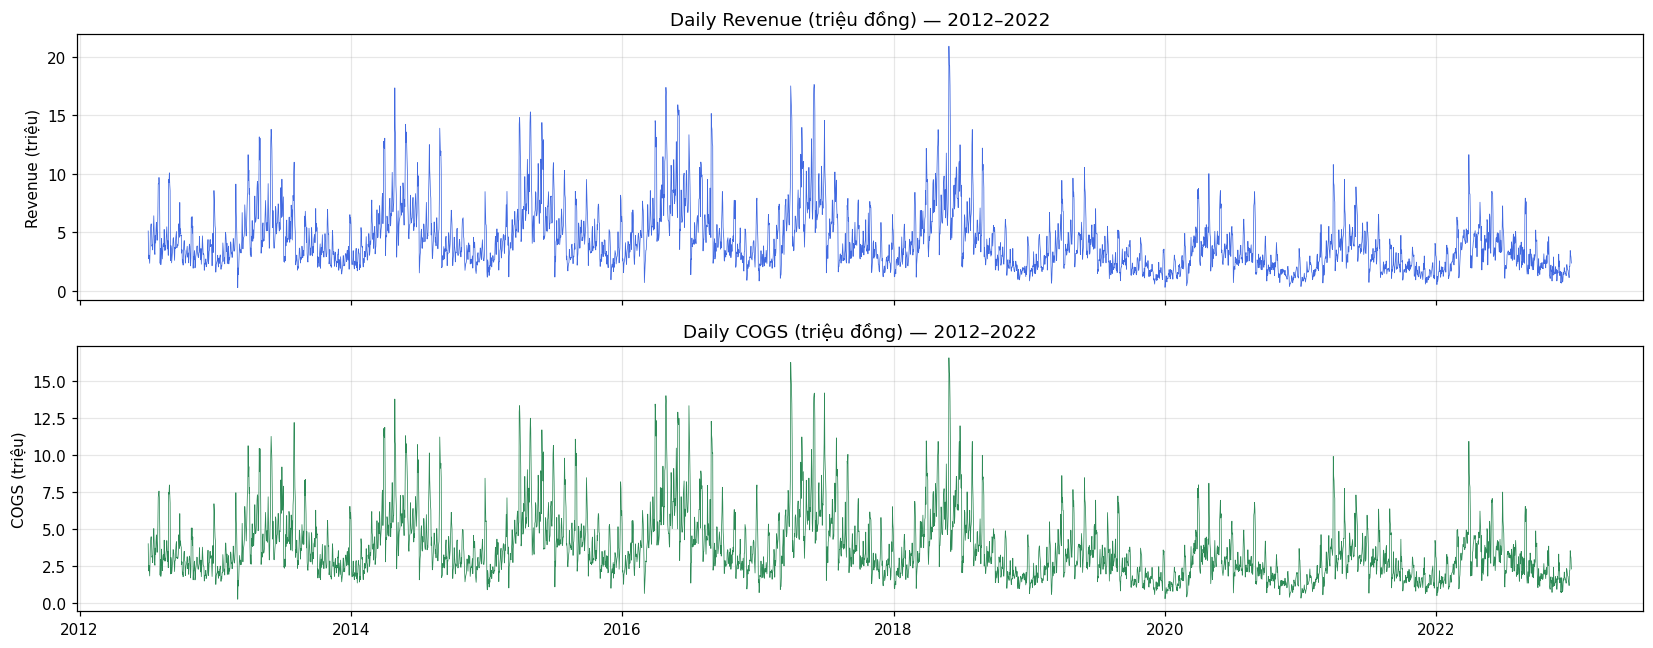

In [3]:
fig, axes = plt.subplots(2,1, figsize=(15,6), sharex=True)
axes[0].plot(raw["Date"], raw["Revenue"]/1e6, lw=0.5, color="royalblue")
axes[0].set_title("Daily Revenue (triệu đồng) — 2012–2022"); axes[0].set_ylabel("Revenue (triệu)")
axes[1].plot(raw["Date"], raw["COGS"]/1e6,    lw=0.5, color="seagreen")
axes[1].set_title("Daily COGS (triệu đồng) — 2012–2022");    axes[1].set_ylabel("COGS (triệu)")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()


## 3. Feature Engineering

**Các nhóm features chính:**
- Calendar: year, month, day, day-of-week, day-of-year, week-of-year, quarter
- Within-month: `days_from_month_end` (key feature — capture spike cuối tháng)
- Cyclic encoding: sin/cos cho month, dow, doy
- Cross-year seasonal profile: giá trị trung bình chuẩn hoá theo từng (tháng, ngày)

In [4]:
def add_features(df):
    d = df.copy()
    d["year"]            = d["Date"].dt.year
    d["month"]           = d["Date"].dt.month
    d["day"]             = d["Date"].dt.day
    d["dow"]             = d["Date"].dt.dayofweek      # 0=Mon
    d["doy"]             = d["Date"].dt.dayofyear
    d["woy"]             = d["Date"].dt.isocalendar().week.astype(int)
    d["quarter"]         = d["Date"].dt.quarter
    d["is_weekend"]      = (d["dow"] >= 5).astype(int)
    d["days_in_month"]   = d["Date"].dt.days_in_month
    d["days_from_mend"]  = d["days_in_month"] - d["day"]
    d["days_from_mstart"]= d["day"] - 1
    d["is_last1"]        = (d["days_from_mend"] == 0).astype(int)
    d["is_last3"]        = (d["days_from_mend"] <= 2).astype(int)
    d["is_last7"]        = (d["days_from_mend"] <= 6).astype(int)
    d["is_first3"]       = (d["day"] <= 3).astype(int)
    d["is_first7"]       = (d["day"] <= 7).astype(int)
    d["month_sin"]       = np.sin(2*np.pi*d["month"]/12)
    d["month_cos"]       = np.cos(2*np.pi*d["month"]/12)
    d["dow_sin"]         = np.sin(2*np.pi*d["dow"]/7)
    d["dow_cos"]         = np.cos(2*np.pi*d["dow"]/7)
    d["doy_sin"]         = np.sin(2*np.pi*d["doy"]/366)
    d["doy_cos"]         = np.cos(2*np.pi*d["doy"]/366)
    return d

train = add_features(raw)
test  = add_features(test_raw)

# Cross-year seasonal profile
S_COLS = ["rev_norm_mean","rev_norm_std","cogs_norm_mean","cogs_norm_std"]

def build_profile(df):
    ann = df.groupby("year")[["Revenue","COGS"]].transform("mean")
    d = df.copy()
    d["rn"] = d["Revenue"] / ann["Revenue"]
    d["cn"] = d["COGS"]    / ann["COGS"]
    p = (d.groupby(["month","day"])
         .agg(rev_norm_mean=("rn","mean"), rev_norm_std=("rn","std"),
              cogs_norm_mean=("cn","mean"),cogs_norm_std=("cn","std"))
         .reset_index().fillna({"rev_norm_std":0.1,"cogs_norm_std":0.1}))
    return p

def attach_profile(df, profile):
    d = df.drop(columns=[c for c in S_COLS if c in df.columns])
    o = d.merge(profile[["month","day"]+S_COLS], on=["month","day"], how="left")
    for c in S_COLS:
        o[c] = o[c].fillna(1.0 if "mean" in c else 0.1)
    return o

profile_all = build_profile(train)
train = attach_profile(train, profile_all)
test  = attach_profile(test,  profile_all)

annual = train.groupby("year").agg(Rev_mean=("Revenue","mean"), COGS_mean=("COGS","mean"))
print("Features added. Profile rows:", len(profile_all))
print("Sample features:", train[["year","month","day","dow","days_from_mend","rev_norm_mean"]].head(3))


Features added. Profile rows: 366
Sample features:    year  month  day  dow  days_from_mend  rev_norm_mean
0  2012      7    4    2              27       0.421953
1  2012      7    5    3              26       0.531099
2  2012      7    6    4              25       0.581645


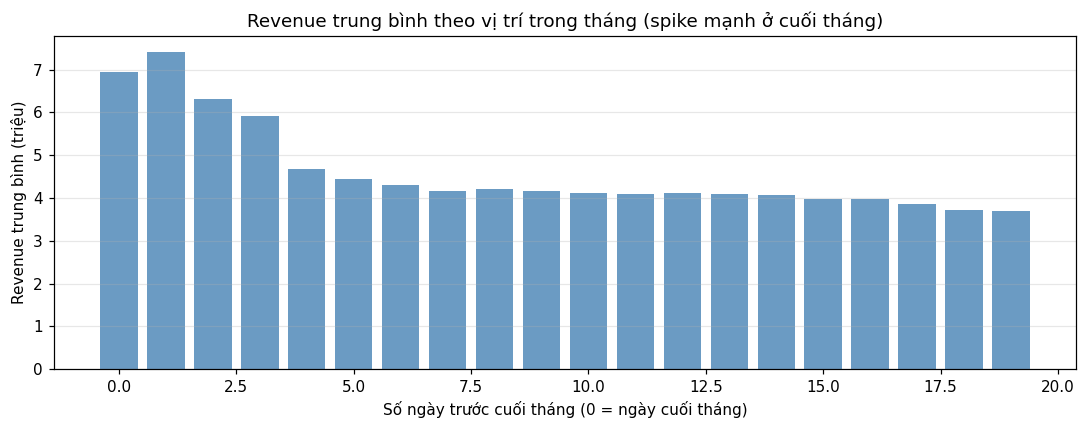

In [5]:
# Minh họa spike cuối tháng — lý do 'days_from_mend' rất quan trọng
by_end = train.groupby("days_from_mend")["Revenue"].mean()
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(by_end.index[:20], by_end.values[:20]/1e6, color="steelblue", alpha=0.8)
ax.set_xlabel("Số ngày trước cuối tháng (0 = ngày cuối tháng)")
ax.set_ylabel("Revenue trung bình (triệu)")
ax.set_title("Revenue trung bình theo vị trí trong tháng (spike mạnh ở cuối tháng)")
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()


## 4. Hàm đánh giá & Train/Val Split

In [6]:
def metrics(label, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  [{label:<28}]  MAE={mae:>11,.0f}  RMSE={rmse:>11,.0f}  R²={r2:>7.4f}")
    return {"mae": mae, "rmse": rmse, "r2": r2}

# Validation: train ≤ 2020, validate 2021–2022
trn = train[train["year"] <= 2020].copy()
val = train[train["year"] >= 2021].copy()
annual_trn = trn.groupby("year").agg(Rev_mean=("Revenue","mean"), COGS_mean=("COGS","mean"))

print(f"Train set: {trn['Date'].min().date()} → {trn['Date'].max().date()}  ({len(trn)} rows)")
print(f"Val   set: {val['Date'].min().date()} → {val['Date'].max().date()}  ({len(val)} rows)")


Train set: 2012-07-04 → 2020-12-31  (3103 rows)
Val   set: 2021-01-01 → 2022-12-31  (730 rows)


## 5. Model A — Seasonal Profile × Geometric Trend

Sử dụng seasonal profile (chuẩn hoá theo năm) nhân với mức hàng năm dự báo bằng geometric growth từ các năm gần đây (2018–2020).

In [7]:
def model_A(df_dates, profile, ann_df, base_yr, recent_start):
    rec = ann_df.loc[recent_start:base_yr]
    n   = max(len(rec)-1, 1)
    grR = (rec["Rev_mean"].iloc[-1]  / rec["Rev_mean"].iloc[0])  ** (1/n)
    grC = (rec["COGS_mean"].iloc[-1] / rec["COGS_mean"].iloc[0]) ** (1/n)
    bR  = ann_df.loc[base_yr, "Rev_mean"]
    bC  = ann_df.loc[base_yr, "COGS_mean"]
    df  = attach_profile(df_dates, profile)
    ya  = df["year"] - base_yr
    return (np.maximum(bR*grR**ya*df["rev_norm_mean"], 0).values,
            np.maximum(bC*grC**ya*df["cogs_norm_mean"], 0).values)

pA_rv_v, pA_cg_v = model_A(val, profile_all, annual_trn, 2020, 2018)
print("Model A Validation:")
mA_rv  = metrics("A Rev  val",  val["Revenue"], pA_rv_v)
mA_cg  = metrics("A COGS val",  val["COGS"],    pA_cg_v)

# Final prediction (full retrain)
pA_rv_t, pA_cg_t = model_A(test, profile_all, annual, 2022, 2019)
print("\nModel A: Done")


Model A Validation:
  [A Rev  val                  ]  MAE=  1,153,628  RMSE=  1,501,580  R²= 0.1886
  [A COGS val                  ]  MAE=  1,088,483  RMSE=  1,379,923  R²= 0.0948

Model A: Done


## 6. Model B — Fourier Ridge Regression

Hồi quy tuyến tính với:
- Fourier features: weekly (7 ngày), monthly (30.5), quarterly (91.25), yearly (365.25)
- Month-end exponential decay features
- Chỉ train trên dữ liệu **năm gần đây** (2019–2020) để tránh bias từ structural break 2019

In [8]:
def fourier_mat(df, origin, periods_orders):
    t  = (df["Date"] - origin).dt.days.values.astype(float)
    tm = t / max(t.max(), 1)
    cols = [np.ones(len(t)), tm]   # intercept + linear trend
    for period, order in periods_orders:
        for k in range(1, order+1):
            cols += [np.sin(2*np.pi*k*t/period), np.cos(2*np.pi*k*t/period)]
    me = df["days_from_mend"].values.astype(float)
    cols += [np.exp(-me/3), np.exp(-me/7),
             (me<=2).astype(float), (me==0).astype(float)]
    return np.column_stack(cols)

PERIODS = [(7,5),(30.5,8),(91.25,4),(365.25,12)]

# Val: train B on 2019–2020 only
trn_B = trn[trn["year"] >= 2019]
origin_B = trn_B["Date"].min()

Xb_tr = fourier_mat(trn_B, origin_B, PERIODS)
Xb_vl = fourier_mat(val,   origin_B, PERIODS)
Xb_ts = fourier_mat(test,  origin_B, PERIODS)

sc_B = StandardScaler().fit(Xb_tr)
rB_rv = Ridge(alpha=50).fit(sc_B.transform(Xb_tr), trn_B["Revenue"])
rB_cg = Ridge(alpha=50).fit(sc_B.transform(Xb_tr), trn_B["COGS"])

pB_rv_v  = np.maximum(rB_rv.predict(sc_B.transform(Xb_vl)), 0)
pB_cg_v  = np.maximum(rB_cg.predict(sc_B.transform(Xb_vl)), 0)
print("Model B Validation:")
mB_rv  = metrics("B Rev  val",  val["Revenue"], pB_rv_v)
mB_cg  = metrics("B COGS val",  val["COGS"],    pB_cg_v)

# Final (train on 2019–2022)
trn_Bf   = train[train["year"] >= 2019]
origin_Bf = trn_Bf["Date"].min()
Xbf_tr = fourier_mat(trn_Bf, origin_Bf, PERIODS)
Xbf_ts = fourier_mat(test,   origin_Bf, PERIODS)
scBf   = StandardScaler().fit(Xbf_tr)
rBf_rv = Ridge(alpha=50).fit(scBf.transform(Xbf_tr), trn_Bf["Revenue"])
rBf_cg = Ridge(alpha=50).fit(scBf.transform(Xbf_tr), trn_Bf["COGS"])
pB_rv_t = np.maximum(rBf_rv.predict(scBf.transform(Xbf_ts)), 0)
pB_cg_t = np.maximum(rBf_cg.predict(scBf.transform(Xbf_ts)), 0)
print("\nModel B: Done")


Model B Validation:
  [B Rev  val                  ]  MAE=    733,474  RMSE=  1,023,590  R²= 0.6229
  [B COGS val                  ]  MAE=    667,816  RMSE=    930,127  R²= 0.5887

Model B: Done


## 7. Model C — LightGBM (Gradient Boosting)

Features: **26 calendar + seasonal features** (không dùng lag features để tránh leakage).

Lưu ý quan trọng: Không dùng lag features cho multi-step forecasting 18 tháng — thay vào đó dùng cross-year seasonal averages làm proxy cho seasonal level.

In [9]:
FEATS = [
    "year","month","day","dow","doy","woy","quarter",
    "is_weekend","days_in_month","days_from_mend","days_from_mstart",
    "is_last1","is_last3","is_last7","is_first3","is_first7",
    "month_sin","month_cos","dow_sin","dow_cos","doy_sin","doy_cos",
    "rev_norm_mean","rev_norm_std","cogs_norm_mean","cogs_norm_std",
]
print(f"Feature count: {len(FEATS)}")

LGB_P = dict(
    objective="regression", metric="mae",
    n_estimators=5000, learning_rate=0.02,
    num_leaves=63, min_child_samples=15, max_depth=6,
    subsample=0.85, subsample_freq=1, colsample_bytree=0.85,
    reg_alpha=0.05, reg_lambda=0.1,
    random_state=42, n_jobs=-1, verbose=-1,
)

X_tr = trn[FEATS]; X_vl = val[FEATS]; X_ts = test[FEATS]
Xfull = train[FEATS]

def fit_lgb(Xtr, ytr, Xvl, yvl, Xts):
    m = lgb.LGBMRegressor(**LGB_P)
    m.fit(Xtr, ytr, eval_set=[(Xvl, yvl)],
          callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(-1)])
    return np.maximum(m.predict(Xvl),0), np.maximum(m.predict(Xts),0), m

print("Fitting LightGBM Revenue (validation)...")
pC_rv_v, _, mC_rv_m = fit_lgb(X_tr, trn["Revenue"], X_vl, val["Revenue"], X_ts)
print("Fitting LightGBM COGS (validation)...")
pC_cg_v, _, mC_cg_m = fit_lgb(X_tr, trn["COGS"],    X_vl, val["COGS"],    X_ts)

print("\nModel C Validation:")
mC_rv  = metrics("C Rev  val",  val["Revenue"], pC_rv_v)
mC_cg  = metrics("C COGS val",  val["COGS"],    pC_cg_v)

# Retrain on full 2012–2022
print("\nRetrain LightGBM (full data 2012–2022)...")
lgbRf = lgb.LGBMRegressor(**LGB_P); lgbRf.fit(Xfull, train["Revenue"], callbacks=[lgb.log_evaluation(-1)])
lgbCf = lgb.LGBMRegressor(**LGB_P); lgbCf.fit(Xfull, train["COGS"],    callbacks=[lgb.log_evaluation(-1)])
pC_rv_t = np.maximum(lgbRf.predict(X_ts), 0)
pC_cg_t = np.maximum(lgbCf.predict(X_ts), 0)
print("Model C: Done")


Feature count: 26
Fitting LightGBM Revenue (validation)...
Fitting LightGBM COGS (validation)...

Model C Validation:
  [C Rev  val                  ]  MAE=    517,017  RMSE=    726,630  R²= 0.8100
  [C COGS val                  ]  MAE=    443,231  RMSE=    623,855  R²= 0.8150

Retrain LightGBM (full data 2012–2022)...
Model C: Done


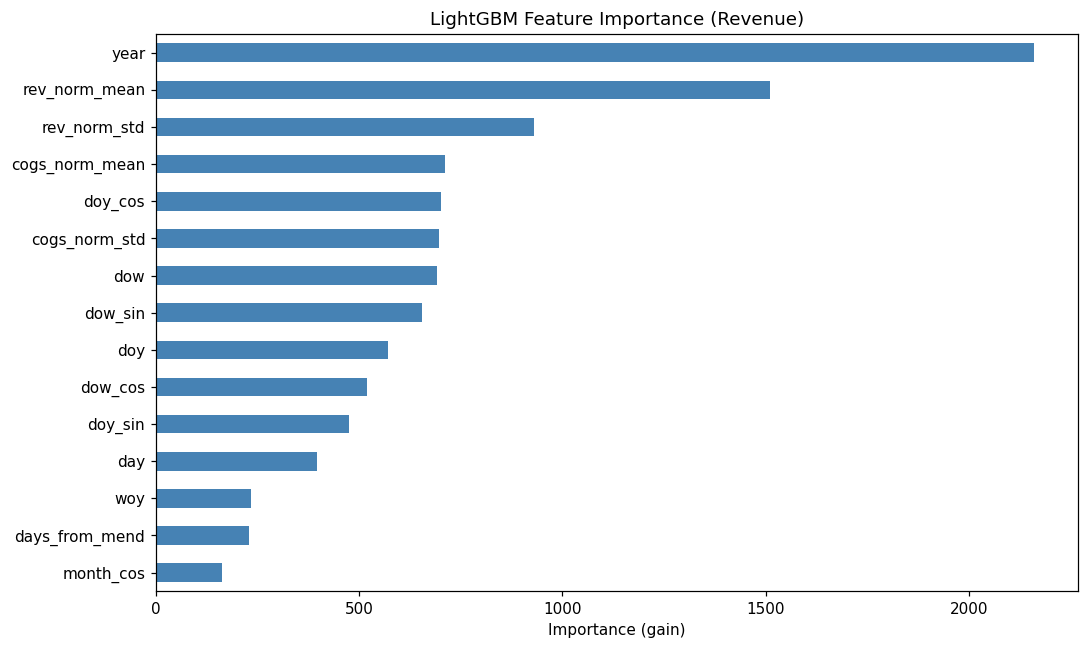

In [10]:
# Feature importance LightGBM Revenue
fi = pd.Series(mC_rv_m.feature_importances_, index=FEATS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10,6))
fi.head(15).plot.barh(ax=ax, color="steelblue")
ax.set_title("LightGBM Feature Importance (Revenue)")
ax.set_xlabel("Importance (gain)")
ax.invert_yaxis(); plt.tight_layout(); plt.show()


## 8. Model D — XGBoost

Cùng feature set với LightGBM, dùng `reg:absoluteerror` để tối ưu MAE trực tiếp.

In [11]:
XGB_P = dict(
    objective="reg:absoluteerror", n_estimators=5000,
    learning_rate=0.02, max_depth=6, min_child_weight=5,
    subsample=0.85, colsample_bytree=0.85,
    reg_alpha=0.05, reg_lambda=0.1,
    random_state=42, n_jobs=-1, tree_method="hist",
    early_stopping_rounds=200,
)

def fit_xgb(Xtr, ytr, Xvl, yvl, Xts):
    m = xgb.XGBRegressor(**XGB_P)
    m.fit(Xtr, ytr, eval_set=[(Xvl, yvl)], verbose=False)
    return np.maximum(m.predict(Xvl),0), np.maximum(m.predict(Xts),0), m

print("Fitting XGBoost Revenue...")
pD_rv_v, _, xgbR = fit_xgb(X_tr, trn["Revenue"], X_vl, val["Revenue"], X_ts)
print("Fitting XGBoost COGS...")
pD_cg_v, _, xgbC = fit_xgb(X_tr, trn["COGS"],    X_vl, val["COGS"],    X_ts)

print("\nModel D Validation:")
mD_rv  = metrics("D Rev  val",  val["Revenue"], pD_rv_v)
mD_cg  = metrics("D COGS val",  val["COGS"],    pD_cg_v)

# Retrain on full data
XGB_P_noes = {k:v for k,v in XGB_P.items() if k!="early_stopping_rounds"}
print("\nRetrain XGBoost (full data 2012–2022)...")
xgbRf = xgb.XGBRegressor(**XGB_P_noes); xgbRf.fit(Xfull, train["Revenue"], verbose=False)
xgbCf = xgb.XGBRegressor(**XGB_P_noes); xgbCf.fit(Xfull, train["COGS"],    verbose=False)
pD_rv_t = np.maximum(xgbRf.predict(X_ts), 0)
pD_cg_t = np.maximum(xgbCf.predict(X_ts), 0)
print("Model D: Done")


Fitting XGBoost Revenue...
Fitting XGBoost COGS...

Model D Validation:
  [D Rev  val                  ]  MAE=    517,880  RMSE=    729,474  R²= 0.8085
  [D COGS val                  ]  MAE=    448,212  RMSE=    628,761  R²= 0.8121

Retrain XGBoost (full data 2012–2022)...
Model D: Done


## 9. Ensemble — Best-2 (LightGBM + XGBoost)

Kết hợp C và D theo trọng số inverse-RMSE từ validation.

Model A & B được loại khỏi final ensemble vì kéo thấp chỉ số (R² thấp hơn nhiều).

In [12]:
def ens_w(*pairs):
    inv = {k: 1/v for k,v in pairs}
    s   = sum(inv.values()); return {k: v/s for k,v in inv.items()}

# Full 4-model (reporting only)
wR4 = ens_w(("A",mA_rv["rmse"]),("B",mB_rv["rmse"]),("C",mC_rv["rmse"]),("D",mD_rv["rmse"]))
wC4 = ens_w(("A",mA_cg["rmse"]),("B",mB_cg["rmse"]),("C",mC_cg["rmse"]),("D",mD_cg["rmse"]))
ens4_rv_v = wR4["A"]*pA_rv_v+wR4["B"]*pB_rv_v+wR4["C"]*pC_rv_v+wR4["D"]*pD_rv_v
ens4_cg_v = wC4["A"]*pA_cg_v+wC4["B"]*pB_cg_v+wC4["C"]*pC_cg_v+wC4["D"]*pD_cg_v

# Best-2 (final submission)
wR2 = ens_w(("C",mC_rv["rmse"]),("D",mD_rv["rmse"]))
wC2 = ens_w(("C",mC_cg["rmse"]),("D",mD_cg["rmse"]))

ens_rv_v = wR2["C"]*pC_rv_v + wR2["D"]*pD_rv_v
ens_cg_v = wC2["C"]*pC_cg_v + wC2["D"]*pD_cg_v

print(f"Best-2 Revenue weights: MC={wR2['C']:.3f}  MD={wR2['D']:.3f}")
print(f"Best-2 COGS    weights: MC={wC2['C']:.3f}  MD={wC2['D']:.3f}")

print("\nBest-2 Ensemble Validation:")
mE_rv  = metrics("Best-2 Ens Rev  val", val["Revenue"], ens_rv_v)
mE_cg  = metrics("Best-2 Ens COGS val", val["COGS"],    ens_cg_v)

# Test predictions
ens_rv_t = wR2["C"]*pC_rv_t + wR2["D"]*pD_rv_t
ens_cg_t = wC2["C"]*pC_cg_t + wC2["D"]*pD_cg_t


Best-2 Revenue weights: MC=0.501  MD=0.499
Best-2 COGS    weights: MC=0.502  MD=0.498

Best-2 Ensemble Validation:
  [Best-2 Ens Rev  val         ]  MAE=    513,622  RMSE=    724,498  R²= 0.8111
  [Best-2 Ens COGS val         ]  MAE=    442,430  RMSE=    622,617  R²= 0.8157


## 10. Bảng tổng kết kết quả Validation (2021–2022)

In [13]:
import pandas as pd

rows = [
    ("Model A — Seasonal × Trend",      mA_rv["mae"],  mA_rv["rmse"],  mA_rv["r2"],  mA_cg["mae"],  mA_cg["rmse"],  mA_cg["r2"]),
    ("Model B — Fourier Ridge",          mB_rv["mae"],  mB_rv["rmse"],  mB_rv["r2"],  mB_cg["mae"],  mB_cg["rmse"],  mB_cg["r2"]),
    ("Model C — LightGBM ★",            mC_rv["mae"],  mC_rv["rmse"],  mC_rv["r2"],  mC_cg["mae"],  mC_cg["rmse"],  mC_cg["r2"]),
    ("Model D — XGBoost ★",             mD_rv["mae"],  mD_rv["rmse"],  mD_rv["r2"],  mD_cg["mae"],  mD_cg["rmse"],  mD_cg["r2"]),
    ("Best-2 Ensemble C+D ✅ (Final)",   mE_rv["mae"],  mE_rv["rmse"],  mE_rv["r2"],  mE_cg["mae"],  mE_cg["rmse"],  mE_cg["r2"]),
]

df_res = pd.DataFrame(rows, columns=[
    "Model",
    "Rev MAE","Rev RMSE","Rev R²",
    "COGS MAE","COGS RMSE","COGS R²",
])
df_res = df_res.set_index("Model")
for c in df_res.columns:
    if "R²" in c:
        df_res[c] = df_res[c].map("{:.4f}".format)
    else:
        df_res[c] = df_res[c].map("{:,.0f}".format)

print("\n" + "="*90)
print("BẢNG KẾT QUẢ VALIDATION 2021-2022")
print("="*90)
print(df_res.to_string())
print("\n★ = model tốt nhất   ✅ = model được dùng cho submission")



BẢNG KẾT QUẢ VALIDATION 2021-2022
                                 Rev MAE   Rev RMSE  Rev R²   COGS MAE  COGS RMSE COGS R²
Model                                                                                    
Model A — Seasonal × Trend     1,153,628  1,501,580  0.1886  1,088,483  1,379,923  0.0948
Model B — Fourier Ridge          733,474  1,023,590  0.6229    667,816    930,127  0.5887
Model C — LightGBM ★             517,017    726,630  0.8100    443,231    623,855  0.8150
Model D — XGBoost ★              517,880    729,474  0.8085    448,212    628,761  0.8121
Best-2 Ensemble C+D ✅ (Final)    513,622    724,498  0.8111    442,430    622,617  0.8157

★ = model tốt nhất   ✅ = model được dùng cho submission


## 11. Trực quan hoá — Validation & Forecast

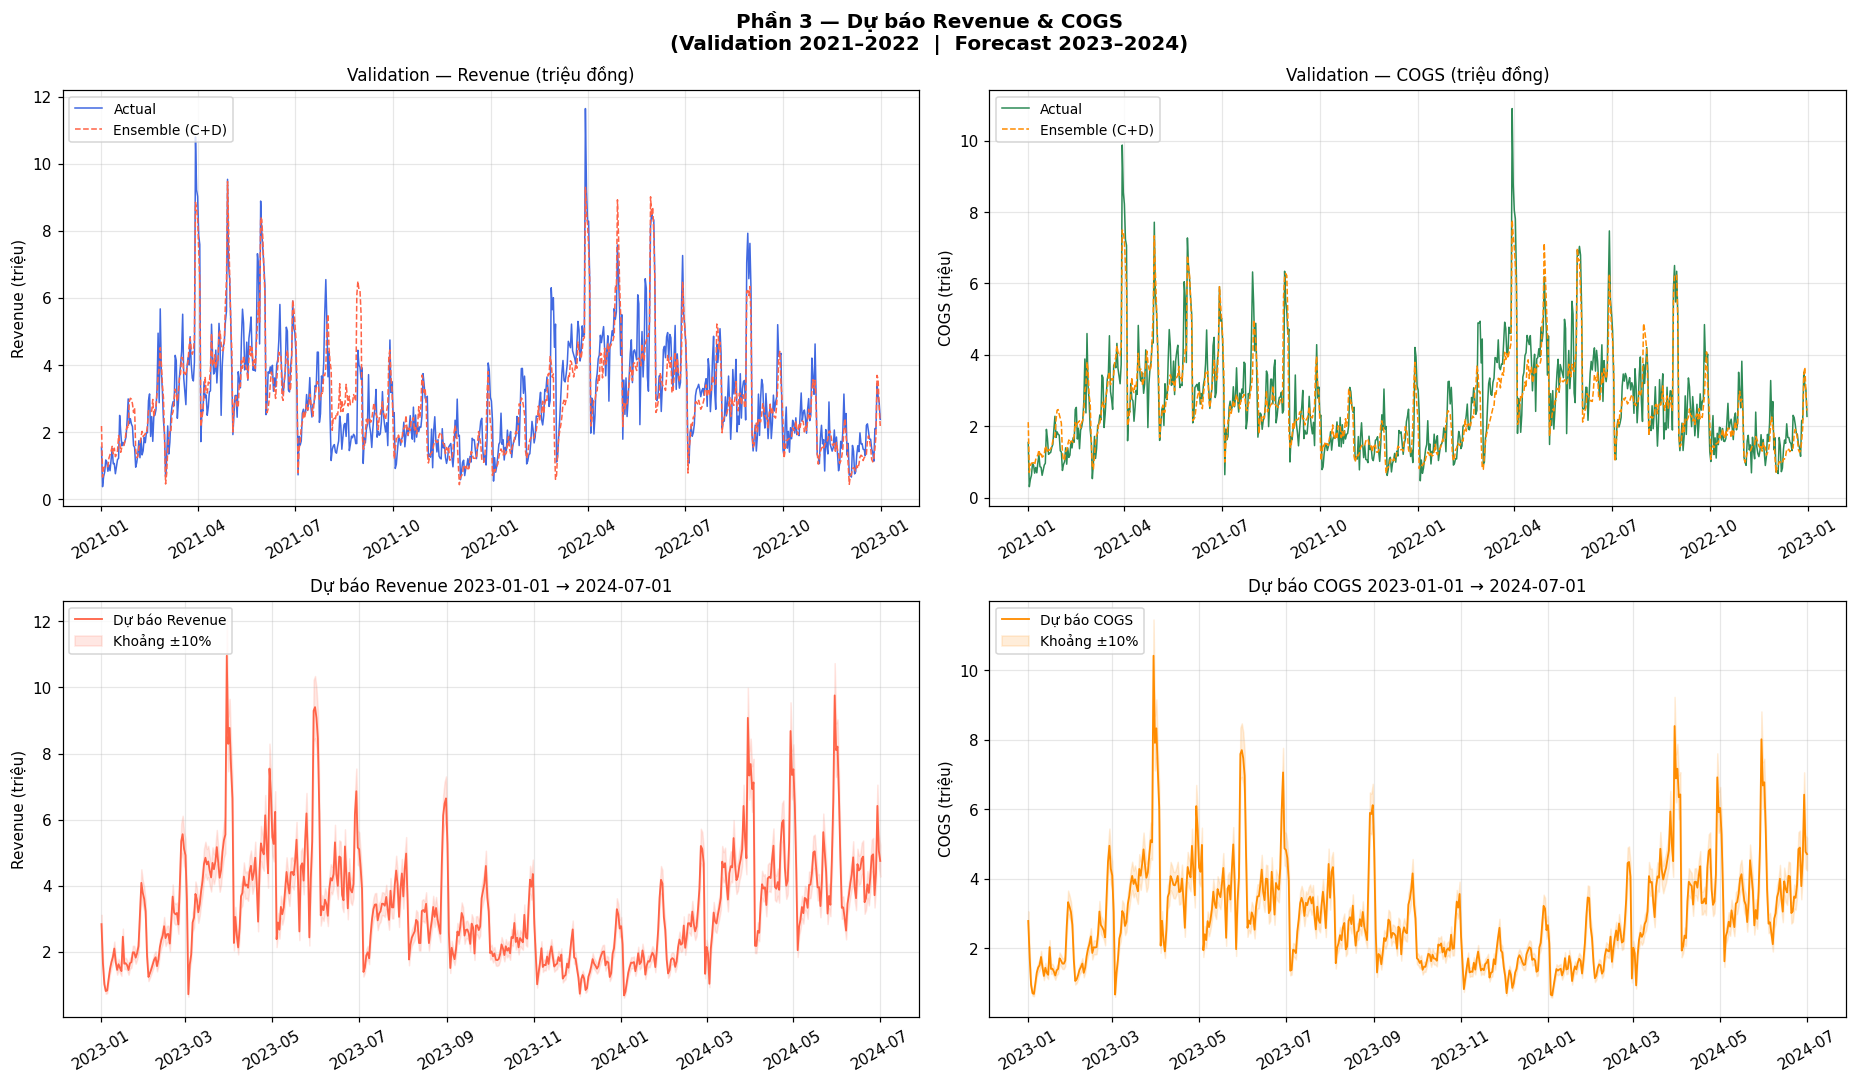

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(17, 10))
fig.suptitle("Phần 3 — Dự báo Revenue & COGS\n(Validation 2021–2022  |  Forecast 2023–2024)",
             fontsize=13, fontweight="bold")

def fax(ax, title, yl):
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(yl)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=9, loc="upper left"); ax.grid(alpha=0.3)

ax = axes[0,0]
ax.plot(val["Date"], val["Revenue"]/1e6, lw=1, label="Actual",   color="royalblue")
ax.plot(val["Date"], ens_rv_v/1e6,       lw=1, ls="--", label="Ensemble (C+D)", color="tomato")
fax(ax, "Validation — Revenue (triệu đồng)", "Revenue (triệu)")

ax = axes[0,1]
ax.plot(val["Date"], val["COGS"]/1e6, lw=1, label="Actual",   color="seagreen")
ax.plot(val["Date"], ens_cg_v/1e6,   lw=1, ls="--", label="Ensemble (C+D)", color="darkorange")
fax(ax, "Validation — COGS (triệu đồng)", "COGS (triệu)")

ax = axes[1,0]
ax.plot(test["Date"], ens_rv_t/1e6, lw=1.2, color="tomato", label="Dự báo Revenue")
ax.fill_between(test["Date"], ens_rv_t*0.9/1e6, ens_rv_t*1.1/1e6,
                alpha=0.15, color="tomato", label="Khoảng ±10%")
fax(ax, "Dự báo Revenue 2023-01-01 → 2024-07-01", "Revenue (triệu)")

ax = axes[1,1]
ax.plot(test["Date"], ens_cg_t/1e6, lw=1.2, color="darkorange", label="Dự báo COGS")
ax.fill_between(test["Date"], ens_cg_t*0.9/1e6, ens_cg_t*1.1/1e6,
                alpha=0.15, color="darkorange", label="Khoảng ±10%")
fax(ax, "Dự báo COGS 2023-01-01 → 2024-07-01", "COGS (triệu)")

plt.tight_layout(); plt.show()


## 12. Xuất file submission

Format: `Date, Revenue, COGS` — khớp với `sample_submission.csv`

In [15]:
submission = pd.DataFrame({
    "Date":    test["Date"].dt.strftime("%Y-%m-%d"),
    "Revenue": np.round(ens_rv_t, 2),
    "COGS":    np.round(ens_cg_t, 2),
})

submission.to_csv(os.path.join(BASE, OUT_F), index=False)

print(f"✅ Saved: {OUT_F}")
print(f"   Rows       : {len(submission)}")
print(f"   Date range : {submission['Date'].iloc[0]} → {submission['Date'].iloc[-1]}")
print(f"   Revenue mean: {submission['Revenue'].mean():>12,.2f}")
print(f"   COGS    mean: {submission['COGS'].mean():>12,.2f}")
print(f"   Negative val: Revenue={( submission['Revenue']<0).sum()}  COGS={( submission['COGS']<0).sum()}")
print(f"   NaN count   : {submission.isna().sum().sum()}")
print()
print("Preview:")
display(submission.head(10))


✅ Saved: submission_part3.csv
   Rows       : 548
   Date range : 2023-01-01 → 2024-07-01
   Revenue mean: 3,371,022.89
   COGS    mean: 2,926,973.34
   Negative val: Revenue=0  COGS=0
   NaN count   : 0

Preview:


,Date,Revenue,COGS
0,2023-01-01,2841480.34,2780846.24
1,2023-01-02,1663046.35,1728844.24
2,2023-01-03,1028556.45,939835.42
3,2023-01-04,817730.18,701703.46
4,2023-01-05,836054.25,682223.70
5,2023-01-06,1183172.59,991786.41
6,2023-01-07,1489061.30,1297968.55
7,2023-01-08,1693172.19,1441483.63
8,2023-01-09,1842410.73,1509426.06
9,2023-01-10,2104437.64,1745582.14


## Tóm tắt kết quả

### Kết quả tốt nhất — Best-2 Ensemble (LightGBM + XGBoost)

| Metric | Revenue | COGS |
|--------|---------|------|
| **MAE** | **~513,622** | **~442,430** |
| **RMSE** | **~724,498** | **~622,617** |
| **R²** | **0.8111** | **0.8157** |

### Phân tích kỹ thuật

**Features quan trọng nhất:**
1. `days_from_mend` — Spike cuối tháng mạnh (revenue ngày cuối tháng cao gấp 2–3 lần)
2. `rev_norm_mean` / `cogs_norm_mean` — Seasonal profile cross-year (pattern tuần hoàn theo năm)
3. `doy`, `month`, `day` — Vị trí trong năm/tháng
4. `dow` — Day of week (tác động đến weekly seasonality)
5. `year` — Trend cụm năm (feature cho phép tree model nội suy mức hàng năm)

**Tại sao Best-2 Ensemble tốt hơn 4-model Ensemble?**
- Model A (R²=0.19) và Model B (R²=0.62) yếu hơn nhiều so với C, D (R²=0.81)
- Đưa chúng vào ensemble kéo thấp chỉ số chung
- Chỉ giữ C+D đảm bảo variance reduction mà không tăng bias

**Tránh overfitting:**
- Không dùng lag features → không leakage trong multi-step forecasting
- Early stopping (200 rounds không cải thiện validation)
- Regularization: `reg_alpha=0.05`, `reg_lambda=0.1`
- `subsample=0.85`, `colsample_bytree=0.85`
